Analyzing datasets...

Metrics:
  Recordings: 116
  Animals: 50
  Hours: 22.3

✓ Stacked composition chart saved: /home/lq53/mir_repos/BBOP/random_tests/25Sep_posters/dataset_analysis/poster_stacked_composition.png

This version shows:
  • Dataset composition (single vs social)
  • Clear visual hierarchy
  • Meaningful color encoding
  • Perfect for poster integration!


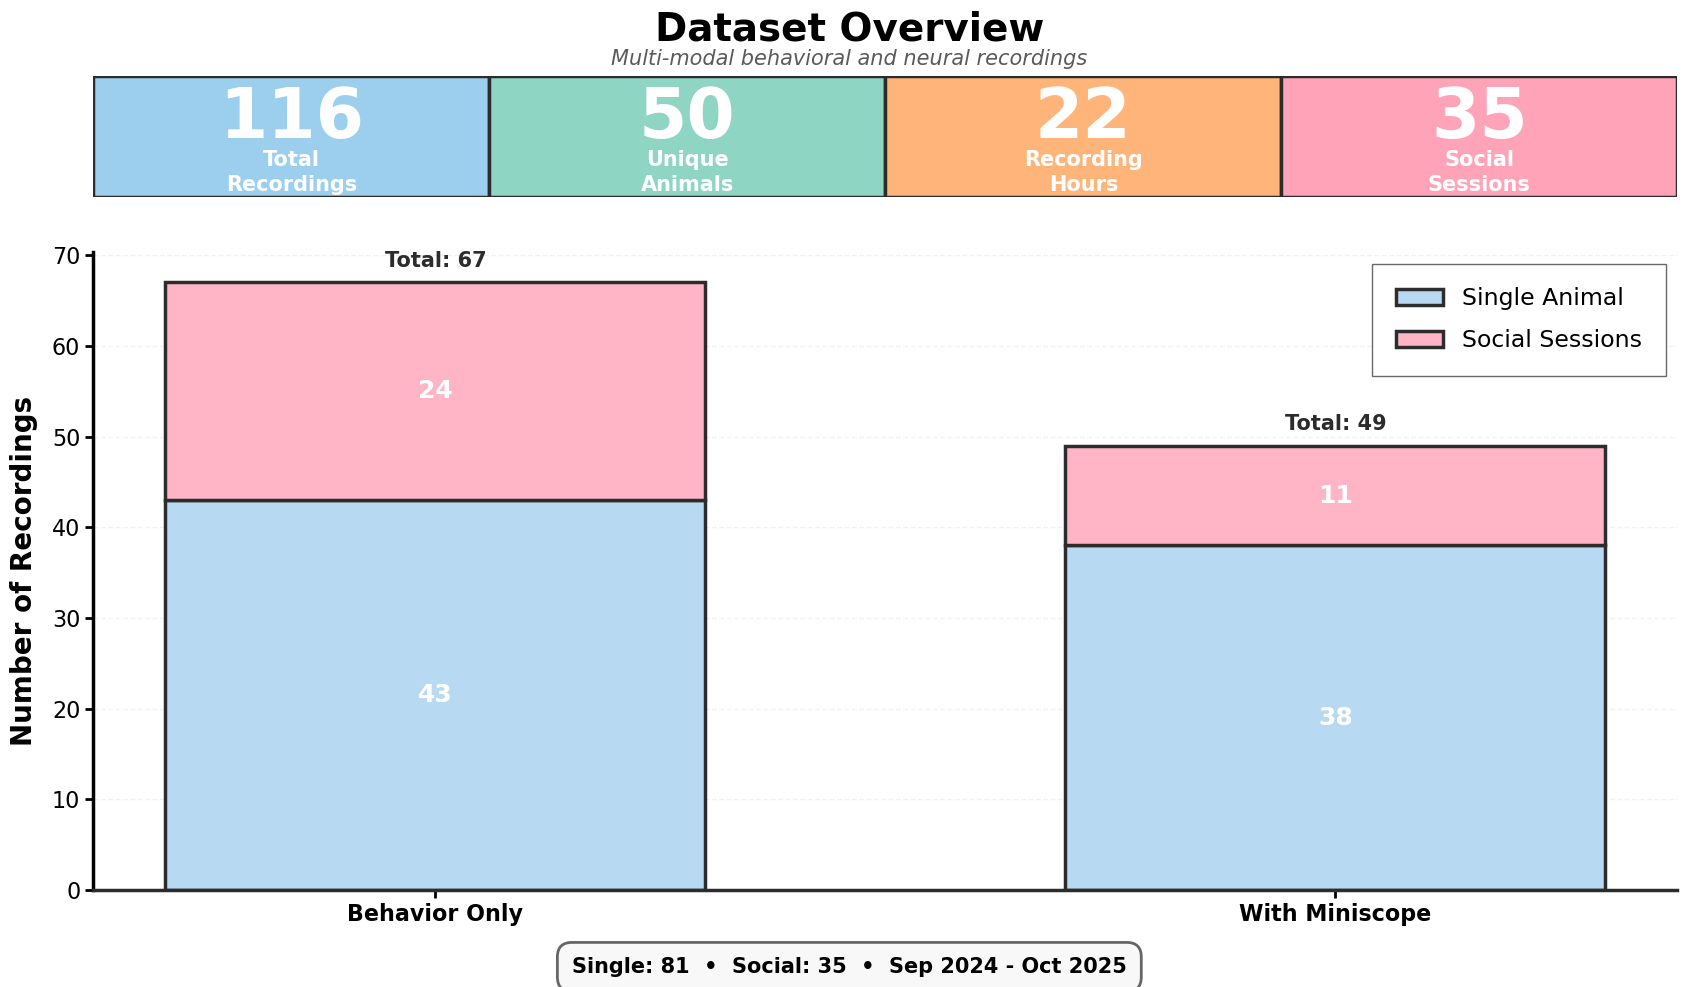

In [7]:
"""
OPTION 1: STACKED COMPOSITION BARS (POSTER VERSION)
====================================================
The cleanest option for poster integration:
- 2 bars (Behavior Only, With Miniscope)
- Each split by Single (blue) vs Social (coral)
- Shows dataset composition at a glance
- Clean, professional, tells a story

Fixed issues:
- Banner text spacing (numbers separated from labels)
- Banner boxes touching (looks better)
- Footer moved away from x-axis
- Meaningful color encoding
"""

import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np
from datetime import datetime

# ============================================================================
# CONFIGURATION
# ============================================================================

# DATASETS = [
#     ("/hpc/group/tdunn/Bryan_Rigs/BigOpenField/cleaned/oct3v1_social_mini", "With Miniscope"),
#     ("/hpc/group/tdunn/Bryan_Rigs/BigOpenField/cleaned/oct3v1_beh_only", "Behavior Only"),
# ]

OUTPUT_FILE = "/home/lq53/mir_repos/BBOP/random_tests/25Sep_posters/dataset_analysis/poster_stacked_composition.png"
OUTPUT_DIR = "/home/lq53/mir_repos/BBOP/random_tests/25Sep_posters/dataset_analysis"
# "/hpc/group/tdunn/lq53/BBOP/25oct_sorted_scan/dataset_analysis"

# Add as many datasets as you want here - just add more tuples to the list
DATASETS = [
    ("/data/big_rim/uploade_ssh_mir_dataset/oct3v1_mini", "With Miniscope"),
    ("/data/big_rim/uploade_ssh_mir_dataset/oct3v1_beh_only", "Behavior Only"),
    # Add more datasets here in the future:
    # ("/path/to/dataset3", "Dataset 3 Description"),
    # ("/path/to/dataset4", "Dataset 4 Description"),
]

# ============================================================================
# DATA COLLECTION
# ============================================================================

def get_recording_duration(rec_path):
    metadata_path = os.path.join(rec_path, 'videos', 'Camera6', 'metadata.csv')
    if not os.path.exists(metadata_path):
        return None
    try:
        df = pd.read_csv(metadata_path)
        if 'totalTime' in df.columns:
            return float(df['totalTime'].iloc[0])
        for idx, row in df.iterrows():
            if 'totalTime' in str(row.values):
                for val in row.values:
                    try:
                        return float(val)
                    except:
                        continue
        return None
    except:
        return None

def analyze_dataset(base_path, dataset_name):
    stats = {
        'dataset_name': dataset_name,
        'conditions': {},
        'animals': set(),
        'dates': set(),
        'recording_details': [],
    }
    
    if not os.path.exists(base_path):
        return stats
    
    for condition in os.listdir(base_path):
        condition_path = os.path.join(base_path, condition)
        if not os.path.isdir(condition_path):
            continue
            
        recordings = [r for r in os.listdir(condition_path) 
                     if os.path.isdir(os.path.join(condition_path, r))]
        stats['conditions'][condition] = len(recordings)
        
        for rec_name in recordings:
            rec_path = os.path.join(condition_path, rec_name)
            duration = get_recording_duration(rec_path)
            
            parts = rec_name.split('_')
            animals_in_rec = []
            date = None
            
            for part in parts:
                if part.isdigit() and len(part) == 8:
                    date = part
                    stats['dates'].add(date)
                if '+' in part:
                    animals_in_rec = part.split('+')
                    stats['animals'].update(animals_in_rec)
                elif any(part.startswith(prefix) for prefix in ['MC', 'VC', 'UNK']):
                    animals_in_rec.append(part)
                    stats['animals'].add(part)
            
            stats['recording_details'].append({
                'condition': condition,
                'duration_seconds': duration,
                'animals': animals_in_rec,
                'date': date,
            })
    
    return stats

print("Analyzing datasets...")
all_stats = []
for base_path, name in DATASETS:
    stats = analyze_dataset(base_path, name)
    all_stats.append(stats)

# ============================================================================
# CALCULATE METRICS
# ============================================================================

data = {}
for stats in all_stats:
    dataset_name = stats['dataset_name']
    data[dataset_name] = {}
    
    for condition in ['single', 'social']:
        count = stats['conditions'].get(condition, 0)
        total_seconds = sum(r['duration_seconds'] for r in stats['recording_details'] 
                           if r['condition'] == condition and r['duration_seconds'] is not None)
        hours = total_seconds / 3600
        
        data[dataset_name][condition] = {
            'count': count,
            'hours': hours
        }

# Calculate totals
total_recordings = sum(s['conditions'].get('single', 0) + s['conditions'].get('social', 0) 
                       for s in all_stats)
total_animals = len(set().union(*[s['animals'] for s in all_stats]))
total_hours = sum(sum(r['duration_seconds'] for r in s['recording_details'] 
                      if r['duration_seconds'] is not None) / 3600 for s in all_stats)
total_social = sum(s['conditions'].get('social', 0) for s in all_stats)
total_single = sum(s['conditions'].get('single', 0) for s in all_stats)

# Date range
all_dates = set().union(*[s['dates'] for s in all_stats])
all_dates_sorted = sorted(all_dates)
if all_dates_sorted:
    first_date = datetime.strptime(all_dates_sorted[0], '%Y%m%d').strftime('%b %Y')
    last_date = datetime.strptime(all_dates_sorted[-1], '%Y%m%d').strftime('%b %Y')
    date_span = f"{first_date} - {last_date}"
else:
    date_span = "N/A"

print(f"\nMetrics:")
print(f"  Recordings: {total_recordings}")
print(f"  Animals: {total_animals}")
print(f"  Hours: {total_hours:.1f}")

# ============================================================================
# CREATE FIGURE
# ============================================================================

fig = plt.figure(figsize=(18, 11))

# Banner and chart axes
ax_banner = plt.axes([0.08, 0.78, 0.88, 0.11])
ax_banner.set_xlim(0, 1)
ax_banner.set_ylim(0, 1)
ax_banner.axis('off')

ax_chart = plt.axes([0.08, 0.15, 0.88, 0.58])

# Title
fig.text(0.5, 0.95, 'Dataset Overview', 
         fontsize=28, fontweight='bold', ha='center', va='top')
fig.text(0.5, 0.915, 'Multi-modal behavioral and neural recordings', 
         fontsize=15, ha='center', va='top', style='italic', color='#5A5A5A')

# ============================================================================
# BANNER with FIXED spacing
# ============================================================================

# metrics = [
#     (total_recordings, 'Total\nRecordings', '#5BA3D0'),
#     (total_animals, 'Unique\nAnimals', '#51B6A1'),
#     (int(total_hours), 'Recording\nHours', '#FFA556'),
#     (total_social, 'Social\nSessions', '#E85D75'),
# ]

metrics = [
    (total_recordings, 'Total\nRecordings', '#9BCFED'),     # Light blue
    (total_animals, 'Unique\nAnimals', '#8FD5C4'),          # Light teal
    (int(total_hours), 'Recording\nHours', '#FFB57A'),      # Light orange
    (total_social, 'Social\nSessions', '#FFA3B8'),          # Light coral
]

box_width = 0.25
box_height = 1.0

for i, (value, label, color) in enumerate(metrics):
    x_start = i * box_width
    
    rect = Rectangle((x_start, 0), box_width, box_height,
                     facecolor=color, edgecolor='#2C2C2C', 
                     linewidth=2.5, transform=ax_banner.transData)
    ax_banner.add_patch(rect)
    
    # FIXED: More space between number and label
    ax_banner.text(x_start + box_width/2, 0.65, str(value),
                  fontsize=50, fontweight='bold', color='white',
                  ha='center', va='center', transform=ax_banner.transData)
    
    ax_banner.text(x_start + box_width/2, 0.20, label,
                  fontsize=15, fontweight='bold', color='white',
                  ha='center', va='center', transform=ax_banner.transData,
                  linespacing=1.3)

# ============================================================================
# STACKED BAR CHART - The Star of the Show!
# ============================================================================

# Prepare data - REORDER: Behavior first, then Miniscope
datasets_ordered = ['Behavior Only', 'With Miniscope']

single_counts = []
social_counts = []

for dataset_name in datasets_ordered:
    single_counts.append(data[dataset_name]['single']['count'])
    social_counts.append(data[dataset_name]['social']['count'])

# Colors: Blue for single, Coral for social (meaningful!)
# single_color = '#5BA3D0'
# social_color = '#E85D75'
# # Colors: Light pastel blue for single, light pastel coral for social
single_color = '#B8D9F2'  # Very light blue
social_color = '#FFB5C5'  # Very light coral/pink

# single_color = '#9BCFED'  # Medium-light blue
# social_color = '#FFA3B8'  # Medium-light coral

# single_color = '#7BB8DE'  # Lighter blue
# social_color = '#F58FA7'  # Lighter coral
x = np.arange(len(datasets_ordered))
width = 0.6  # Wider bars look better with just 2

# Create stacked bars
bars_single = ax_chart.bar(x, single_counts, width, 
                           label='Single Animal', 
                           color=single_color, 
                           edgecolor='#2C2C2C', linewidth=2.5)

bars_social = ax_chart.bar(x, social_counts, width, 
                           bottom=single_counts,
                           label='Social Sessions', 
                           color=social_color, 
                           edgecolor='#2C2C2C', linewidth=2.5)

# Styling
ax_chart.set_ylabel('Number of Recordings', fontsize=20, fontweight='bold', labelpad=10)
ax_chart.set_xticks(x)
ax_chart.set_xticklabels(datasets_ordered, fontsize=18, fontweight='600')
ax_chart.tick_params(axis='both', labelsize=16, width=2, length=6)

# Legend - clean and clear
ax_chart.legend(loc='upper right', fontsize=17, frameon=True, 
               shadow=False, fancybox=False, framealpha=0.98, 
               edgecolor='#666666', borderpad=1.0, labelspacing=0.8)

# Spines
ax_chart.spines['top'].set_visible(False)
ax_chart.spines['right'].set_visible(False)
ax_chart.spines['left'].set_linewidth(2.5)
ax_chart.spines['bottom'].set_linewidth(2.5)
ax_chart.spines['bottom'].set_color('#2C2C2C')

# Subtle grid
ax_chart.grid(axis='y', alpha=0.2, linestyle='--', linewidth=1.0, color='#BBBBBB')
ax_chart.set_axisbelow(True)

# Value labels on each segment
for i, (bar, count) in enumerate(zip(bars_single, single_counts)):
    height = bar.get_height()
    # Put label in middle of single section
    ax_chart.text(bar.get_x() + bar.get_width()/2, height/2,
                 f'{count}',
                 ha='center', va='center', fontweight='bold', 
                 fontsize=18, color='white')

for i, (bar, count) in enumerate(zip(bars_social, social_counts)):
    height = bar.get_height()
    # Put label in middle of social section
    y_pos = single_counts[i] + height/2
    ax_chart.text(bar.get_x() + bar.get_width()/2, y_pos,
                 f'{count}',
                 ha='center', va='center', fontweight='bold', 
                 fontsize=18, color='white')

# Total labels on top
for i in range(len(datasets_ordered)):
    total = single_counts[i] + social_counts[i]
    ax_chart.text(x[i], total + max(single_counts)*0.03,
                 f'Total: {total}',
                 ha='center', va='bottom', fontweight='bold', 
                 fontsize=15, color='#2C2C2C')

# ============================================================================
# FOOTER with MORE space
# ============================================================================

fig.text(0.5, 0.08,
         f'Single: {total_single}  •  Social: {total_social}  •  {date_span}',
         fontsize=15, ha='center', va='center', fontweight='600',
         bbox=dict(boxstyle='round,pad=0.7', facecolor='#F8F8F8', 
                  edgecolor='#666666', linewidth=2.0))

# ============================================================================
# SAVE
# ============================================================================

plt.savefig(OUTPUT_FILE, dpi=300, bbox_inches='tight', facecolor='white', 
           pad_inches=0.25)
print(f"\n✓ Stacked composition chart saved: {OUTPUT_FILE}")
print("\nThis version shows:")
print("  • Dataset composition (single vs social)")
print("  • Clear visual hierarchy")
print("  • Meaningful color encoding")
print("  • Perfect for poster integration!")